Dataset Shape: (10100, 31)

First 5 Rows:
     Time        V1        V2        V3        V4        V5        V6  \
0  144840  0.692293  1.346626  0.000132 -0.164793 -1.060724 -0.242730   
1   21806 -0.821399  0.239392  1.520921 -0.970029 -0.005292  0.495531   
2   70665 -2.291128 -1.186913  1.765915  0.326060 -2.699667  0.069721   
3  165892 -0.521862 -0.605799 -0.152037 -1.722696  0.027497 -0.785445   
4  147377  0.237830  0.479625 -0.432301  0.231731 -0.927373  1.288434   

         V7        V8        V9  ...       V21       V22       V23       V24  \
0  1.157356 -1.447010  1.054074  ...  0.512264 -1.399158  1.013787  0.531163   
1 -1.568072  2.021891 -0.826400  ...  0.757904 -1.446299  1.704211  1.439465   
2  1.802636  0.273796  0.044396  ... -0.901120  0.469443  0.178803  0.286230   
3  0.485948 -0.845642  0.746106  ... -0.018897 -1.869563  1.087344 -0.085004   
4 -0.634275  1.128847 -0.233607  ...  0.480064  1.383195  1.266330  0.709933   

        V25       V26       V27       

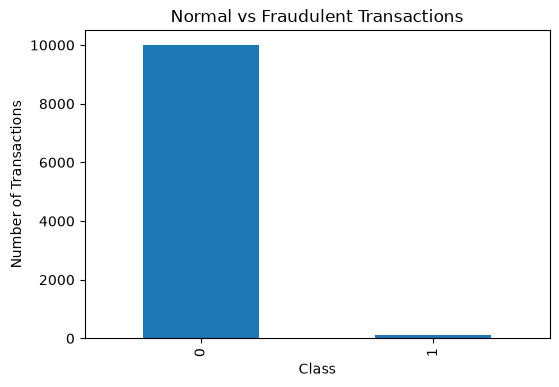


Normal Transactions: 8000
Fraud Transactions: 80
Scale Pos Weight: 100.0

ROC-AUC: 0.8567750000000001
PR-AUC: 0.13291902368349368

Confusion Matrix:
[[1999    1]
 [  19    1]]

True Negatives : 1999
False Positives: 1
False Negatives: 19
True Positives : 1

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2000
           1       0.50      0.05      0.09        20

    accuracy                           0.99      2020
   macro avg       0.75      0.52      0.54      2020
weighted avg       0.99      0.99      0.99      2020


Performance Metrics
Accuracy : 0.9900990099009901
Precision: 0.5
Recall   : 0.05
F1 Score : 0.09090909090909091
ROC-AUC  : 0.8567750000000001
PR-AUC   : 0.13291902368349368


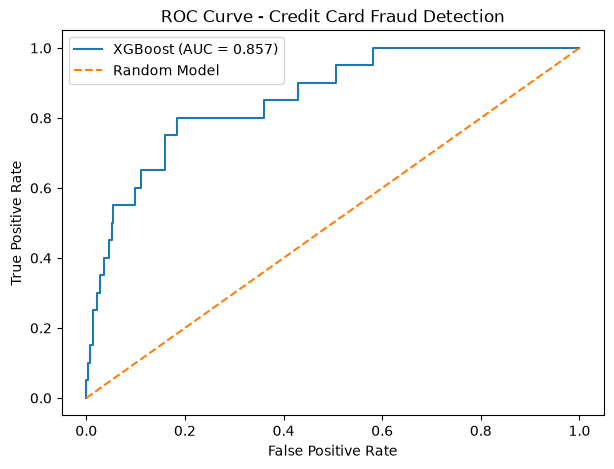


Top 10 Important Features:
V9        0.057167
V13       0.052685
V18       0.050158
V1        0.049811
V8        0.047186
V17       0.043205
V19       0.043057
V7        0.040005
V22       0.038285
Amount    0.036014
dtype: float32


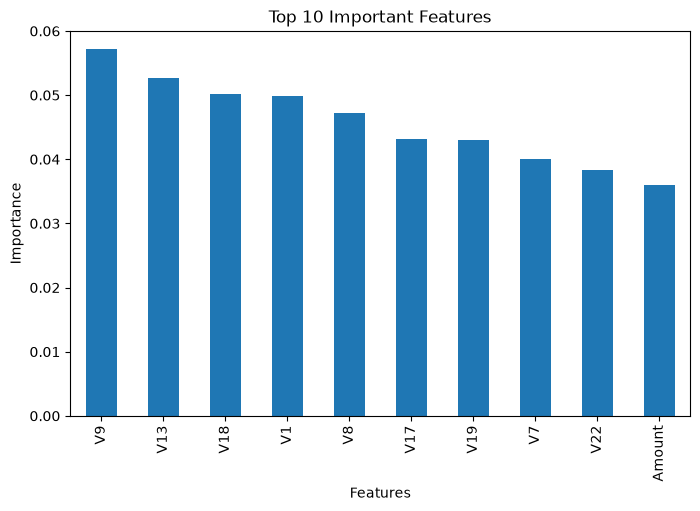

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

from xgboost import XGBClassifier


df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())



print("\nClass Distribution:")
print(df["Class"].value_counts())

print("\nClass Percentage:")
print(df["Class"].value_counts(normalize=True) * 100)



df["Class"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.show()



X = df.drop("Class", axis=1)

y = df["Class"]



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)



negative = (y_train == 0).sum()

positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("\nNormal Transactions:", negative)

print("Fraud Transactions:", positive)

print("Scale Pos Weight:", scale_pos_weight)



model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42
)



model.fit(
    X_train,
    y_train
)



y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]



roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("\nROC-AUC:", roc_auc)



pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("PR-AUC:", pr_auc)


cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)



print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)



accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("\nPerformance Metrics")

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

print("ROC-AUC  :", roc_auc)

print("PR-AUC   :", pr_auc)



fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Credit Card Fraud Detection")

plt.legend()

plt.show()



importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

print("\nTop 10 Important Features:")

print(importance.head(10))



importance.head(10).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Top 10 Important Features")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()